<a href="https://colab.research.google.com/github/AndresMontesDeOca/NLP_1/blob/main/Desafios/Desafio_3_AndresMontesDeOca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

# Desafio #3

## Objetivo Principal
Crear y entrenar un modelo de lenguaje basado en redes neuronales recurrentes que utilice tokenización por caracteres en lugar de por palabras, para luego generar nuevas secuencias de texto.

In [1]:
# !pip install -q gdown PyPDF2 wandb

import pandas as pd
import numpy as np
import gdown
import PyPDF2
import matplotlib.pyplot as plt
import wandb
from google.colab import userdata

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.preprocessing.sequence import pad_sequences

pd.set_option('display.max_colwidth', None)

# Inicializar y loguearse en Weights & Biases
wandb_api_key = userdata.get('WANDB_API_KEY')
wandb.login(key=wandb_api_key)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 19.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: amontesdeoca1982 (andresmontesdeoca) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 1. Selección y Preprocesamiento del Corpus
*   **Selección de datos:** Elegir un corpus de texto (se recomienda reutilizar el conjunto de datos de trabajos previos). Si se presentan problemas de velocidad o memoria por el tamaño del corpus, se permite reducir la cantidad de capítulos o texto utilizado.
*   **Preparación y Tokenización:** Realizar el preprocesamiento necesario para tokenizar el texto a nivel de caracteres y estructurar el dataset.
*   **Ventana de contexto:** Definir y justificar el tamaño de la ventana de contexto analizando la distribución de los datos mediante **histogramas**. Aplicar truncado y *padding* según corresponda.
*   **Split:** Separar el dataset estructurado en conjuntos de entrenamiento (*train*) y validación (*validation*).

### 1.1 Data Load

In [2]:
# Descargar el archivo desde Google Drive usando su ID
file_id = '0Bzr5RihQVFTfWndxTG43cVVPcnM'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'comunidad_del_anillo.pdf'
gdown.download(url, output, quiet=False)

# Extraer el texto del PDF
text = ""
with open(output, 'rb') as file:
    reader = PyPDF2.PdfReader(file)
    for page in reader.pages:
        extracted = page.extract_text()
        if extracted:
            text += extracted + " "

# Reemplazar los saltos de línea (renglones del PDF) por espacios
text = text.replace('\n', ' ')

# Dividir el texto en oraciones utilizando el punto
lineas = text.split('.')

df_lotr = pd.DataFrame(lineas, columns=['oracion'])
# Filtrar líneas vacías
df_lotr = df_lotr[df_lotr['oracion'].str.strip() != '']

print(f"Cantidad de oraciones extraídas: {df_lotr.shape[0]}")
df_lotr.head(5)

Downloading...
From: https://drive.google.com/uc?id=0Bzr5RihQVFTfWndxTG43cVVPcnM
To: /content/comunidad_del_anillo.pdf
100%|██████████| 1.32M/1.32M [00:00<00:00, 180MB/s]


Cantidad de oraciones extraídas: 11107


,oracion
0,"El Señor de los Anillos JRR Tolkien PARTE I: La Comunidad del Anillo PROLOGO 1 De los Hobbits Este libro trata principalmente de los Hobbits, y el lector descubrirá en sus páginas mucho del carácter y algo de la historia de este pueblo"
1,Podrá encontrarse más información en los extractos del Libro Rojo de la Frontera de l Oeste que ya han sido publicados con el título de El Hobbit
2,"El relato tuvo su origen en los primeros capítulos del Libro Rojo, compuesto por Bilbo Bolsón -el primer Hobbit que fue famoso en el mundo entero - y que él tituló Historia de una ida y de una vuelta, pues contaba el viaje de Bilbo hacia el Este y la vuelta, aventura que más tarde enredaría a todos los Hobbits en los importantes acontecimientos que aquí se relatan"
3,"No obstante, muchos querrán saber desde un principio algo más de este pueblo notable y quizás algunos no tengan el libro anterior"
4,"Para esos lectores se han reunido aquí algunas notas sobre los puntos más importantes de la tradición hobbit, y se recuerda brevemente la primera aventura"


### 1.2 Preparación y Tokenización

In [3]:
# Obtener el vocabulario (caracteres únicos en el texto)
vocab = sorted(set(text))
print(f'Número de caracteres únicos (tamaño del vocabulario): {len(vocab)}')

# Crear diccionarios para mapear caracteres a índices y viceversa
char2idx = {u: i for i, u in enumerate(vocab)}
idx2char = np.array(vocab)

# Convertir el texto completo a una secuencia de enteros
text_as_int = np.array([char2idx[c] for c in text])

print("\nTexto original (primeros 50 caracteres):")
print(repr(text[:50]))
print("\nTexto tokenizado (primeros 50 enteros):")
print(text_as_int[:50])


Número de caracteres únicos (tamaño del vocabulario): 95

Texto original (primeros 50 caracteres):
'El Señor de los Anillos   JRR Tolkien     PARTE I:'

Texto tokenizado (primeros 50 enteros):
[26 60  0 40 53 89 63 66  0 52 53  0 60 63 67  0 22 62 57 60 60 63 67  0
  0  0 31 39 39  0 41 63 60 59 57 53 62  0  0  0  0  0 37 22 39 41 26  0
 30 19]


### 1.3 Ventana de Contexto

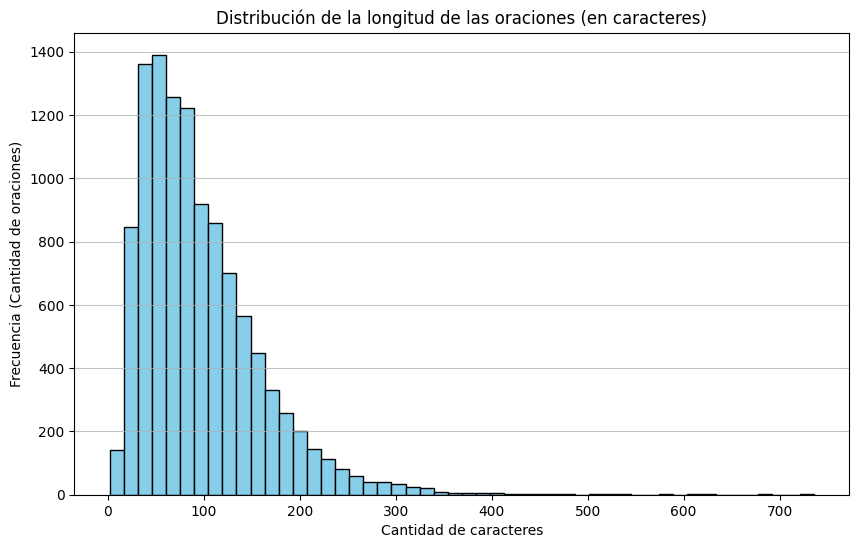

Estadísticas de la longitud de oraciones (en caracteres):
count    11107.000000
mean        95.813901
std         61.647345
min          2.000000
25%         51.000000
50%         82.000000
75%        126.000000
max        736.000000
dtype: float64


In [4]:
# Calcular la longitud de cada oración en caracteres
length_sentences_chars = [len(oracion) for oracion in df_lotr['oracion']]

# Graficar el histograma
plt.figure(figsize=(10, 6))
plt.hist(length_sentences_chars, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de la longitud de las oraciones (en caracteres)')
plt.xlabel('Cantidad de caracteres')
plt.ylabel('Frecuencia (Cantidad de oraciones)')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Mostrar algunas estadísticas descriptivas
print("Estadísticas de la longitud de oraciones (en caracteres):")
print(pd.Series(length_sentences_chars).describe())

In [5]:
# Percentil 90
max_context_size = int(np.percentile(length_sentences_chars, 90) - 1)

print(f'max_context_size: {max_context_size}')

max_context_size: 174


In [6]:
# Generar secuencias usando una ventana deslizante sobre el texto completo
# Esto permite que el modelo aprenda de TODAS las transiciones de caracteres, no solo del final de la oración.
step = 3 # Avanzamos de a 3 caracteres para que el dataset no sea gigante y colapse la RAM
secuencias = []

for i in range(0, len(text_as_int) - max_context_size, step):
    secuencias.append(text_as_int[i : i + max_context_size + 1])

padded_sequences = np.array(secuencias)
print(f"Total de secuencias generadas con sliding window: {len(padded_sequences)}")
print(f"Forma de las secuencias: {padded_sequences.shape}")


Total de secuencias generadas con sliding window: 358425
Forma de las secuencias: (358425, 175)


### 1.4 Split

In [7]:
# Separar en X (entradas) e y (targets)
X = padded_sequences[:, :-1]
y = padded_sequences[:, -1]
print(f"Dimensiones de X (entradas): {X.shape}")
print(f"Dimensiones de y (targets): {y.shape}")

# Split en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_val: {X_val.shape}")

Dimensiones de X (entradas): (358425, 174)
Dimensiones de y (targets): (358425,)

Tamaño de X_train: (286740, 174)
Tamaño de X_val: (71685, 174)


## 2. Arquitectura y Entrenamiento
*   **Modelos:** Proponer arquitecturas de redes neuronales recurrentes. Se sugiere explorar *SimpleRNN* (celda de Elman) como línea base, para luego enfocarse en arquitecturas más robustas como **LSTM** o **GRU**.
*   **Optimizador:** Se recomienda el uso de `rmsprop` para lograr una buena convergencia, aunque es válido experimentar con otros.
*   **Métrica y Early Stopping:** El entrenamiento debe guiarse por el descenso de la **perplejidad** en los datos de validación (utilizar el *callback* provisto para finalizar el entrenamiento en el momento óptimo).
*   **Hardware:** Se requiere utilizar una GPU para mejorar los tiempos de procesamiento.

### 2.1 Arquitectura

In [25]:
tf.keras.backend.clear_session() # Limpia la sesión de Keras para liberar memoria y asegurar una inicialización desde cero

vocab_size = len(vocab)

# Regla heurística de fast.ai
embedding_dim = int(min(600, round(1.6 * vocab_size**0.56)))
print(f"Dimensión del embedding calculada: {embedding_dim}")

model = Sequential()

# Capa de entrada (definimos input_shape para poder construir el summary)
model.add(Embedding(input_dim=vocab_size+1, output_dim=embedding_dim, input_shape=(max_context_size,)))

# Arquitectura pedida: Dos capas LSTM con Dropout
model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.25))
model.add(LSTM(64))
model.add(Dropout(0.25))

# --- CAPA DENSA INTERMEDIA ---
model.add(Dense(128, activation='relu'))

# Capa de salida
model.add(Dense(vocab_size+1, activation='softmax'))

# Compilación
model.compile(loss=SparseCategoricalCrossentropy(), optimizer='rmsprop', metrics=['accuracy'])

model.summary()


Dimensión del embedding calculada: 20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 174, 20)        │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 174, 128)       │        76,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 174, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │        12,384 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,320 (579.38 KB)

 Trainable params: 148,320 (579.38 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2 Entrenamiento

In [26]:
# Nombre de la corrida (se usará para W&B y para guardar el modelo)
run_name = "run_5"

# Configurar Early Stopping guiado por val_loss
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    mode='min'
)

# Callback personalizado para imprimir solo la val_perplexity
class PerplexityCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get('val_loss')
        if val_loss is not None:
            val_perp = np.exp(val_loss)
            print(f"Epoch {epoch+1}/{self.params['epochs']} - val_perplexity: {val_perp:.4f}")

# Entrenar el modelo
epochs = 30
batch_size = 512 # Lote grande para máxima velocidad de iteración

# Calcular la cantidad total de parámetros del modelo
total_params = model.count_params()

# Inicializar el Run de W&B ANTES del entrenamiento registrando la CONFIGURACIÓN
run = wandb.init(
    project="NLP1",
    name=run_name, # <-- Usamos la variable para el nombre
    reinit=True,
    config={
        "vocab_size": vocab_size,
        "max_context_size": max_context_size,
        "embedding_dim": embedding_dim,
        "lstm_units": "128_64",
        "dense_units": 128, # <-- Registramos la capa densa ajustada a 128
        "dropout": 0.25,
        "epochs": epochs,
        "batch_size": batch_size,
        "optimizer": "rmsprop",
        "loss": "SparseCategoricalCrossentropy",
        "architecture": f"Embedding({embedding_dim}) -> LSTM(128) -> Dropout(0.25) -> LSTM(64) -> Dropout(0.25) -> Dense(128, relu) -> Dense({vocab_size+1})",
        "total_params": total_params
    }
)

print(f"Iniciando el entrenamiento (parámetros: {total_params})...")
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping, PerplexityCallback()],
    verbose=0  # Silencia la salida estándar, usamos nuestro callback
)


Iniciando el entrenamiento (parámetros: 148320)...
Epoch 1/30 - val_perplexity: 18.4980
Epoch 2/30 - val_perplexity: 11.4322
Epoch 3/30 - val_perplexity: 9.3116
Epoch 4/30 - val_perplexity: 8.7732
Epoch 5/30 - val_perplexity: 8.2170
Epoch 6/30 - val_perplexity: 7.7900
Epoch 7/30 - val_perplexity: 7.4136
Epoch 8/30 - val_perplexity: 7.0451
Epoch 9/30 - val_perplexity: 6.9780
Epoch 10/30 - val_perplexity: 6.4977
Epoch 11/30 - val_perplexity: 6.1952
Epoch 12/30 - val_perplexity: 6.0105
Epoch 13/30 - val_perplexity: 5.9659
Epoch 14/30 - val_perplexity: 5.8298
Epoch 15/30 - val_perplexity: 5.6113
Epoch 16/30 - val_perplexity: 5.4578
Epoch 17/30 - val_perplexity: 5.3830
Epoch 18/30 - val_perplexity: 5.2825
Epoch 19/30 - val_perplexity: 5.1977
Epoch 20/30 - val_perplexity: 5.1496
Epoch 21/30 - val_perplexity: 5.1217
Epoch 22/30 - val_perplexity: 4.9736
Epoch 23/30 - val_perplexity: 4.9788
Epoch 24/30 - val_perplexity: 4.8469
Epoch 25/30 - val_perplexity: 4.8524
Epoch 26/30 - val_perplexity: 4

In [27]:
# Loguear todo a W&B DESPUÉS de entrenar
print("Entrenamiento finalizado. Registrando historial completo en W&B...")

hist = history.history

# Guardamos los valores de perplejidad (solo validación)
val_perp = [np.exp(l) for l in hist['val_loss']] if 'val_loss' in hist else []

for i in range(len(hist['loss'])):
    log_metrics = {
        'epoch': i + 1,
        'loss': hist['loss'][i],
        'accuracy': hist['accuracy'][i]
    }
    if 'val_loss' in hist:
        log_metrics['val_loss'] = hist['val_loss'][i]
        log_metrics['val_accuracy'] = hist['val_accuracy'][i]
        log_metrics['val_perplexity'] = val_perp[i] # Solo enviamos val_perplexity a W&B

    wandb.log(log_metrics)

# Finalizar el Run
run.finish()
print("✅ Datos subidos a W&B exitosamente.")

# Exportar el modelo entrenado con el nombre de la corrida
model_filename = f'{run_name}.keras'
model.save(model_filename)
print(f"Modelo guardado exitosamente como '{model_filename}'")


Entrenamiento finalizado. Registrando historial completo en W&B...


accuracy,▁▂▃▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇█████████
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
loss,█▆▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▂▃▃▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇███████
val_loss,█▆▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_perplexity,█▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
accuracy,0.51461
epoch,30
loss,1.62078
val_accuracy,0.54447
val_loss,1.53196


✅ Datos subidos a W&B exitosamente.
Modelo guardado exitosamente como 'run_5.keras'


In [ ]:
# # =============================================================================
# # Cargar el modelo guardado
# # =============================================================================

# # Cuando vuelvas a abrir la notebook, ejecuta esto en lugar de entrenar:
# model = load_model('modelname.keras')
# print("Modelo cargado correctamente. Listo para generar texto.")

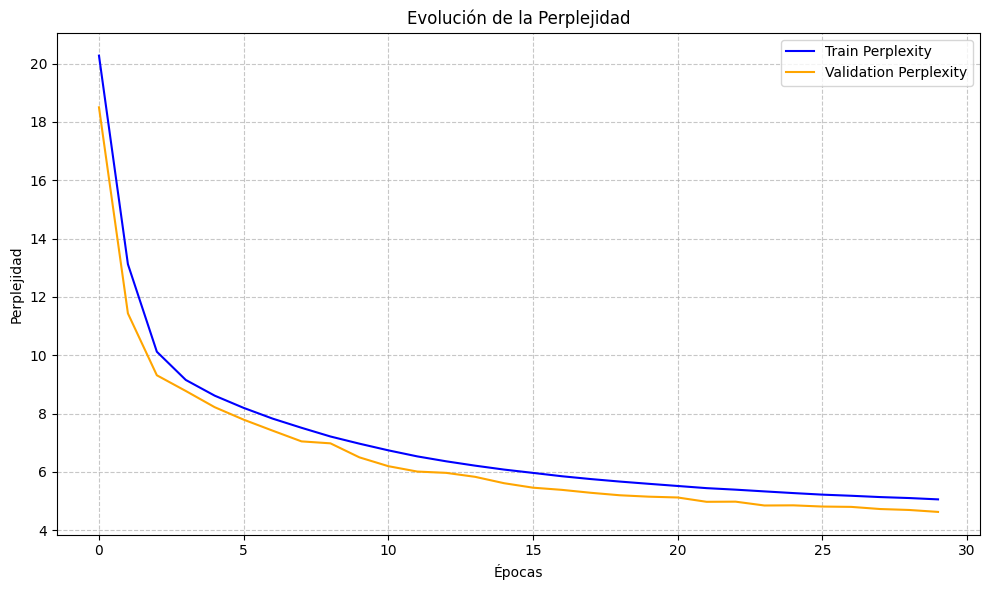

In [28]:
# Plot del entrenamiento (Solo Perplejidad: Train vs Valid)

# Nos aseguramos de que el entrenamiento haya generado el objeto history
if 'history' in locals():
    hist = history.history

    plt.figure(figsize=(10, 6))

    # Gráfico de Perplejidad (Train)
    train_perp = [np.exp(l) for l in hist['loss']]
    plt.plot(train_perp, label='Train Perplexity', color='blue')

    # Gráfico de Perplejidad (Validación)
    if 'val_loss' in hist:
        val_perp = [np.exp(l) for l in hist['val_loss']]
        plt.plot(val_perp, label='Validation Perplexity', color='orange')

    plt.title('Evolución de la Perplejidad')
    plt.xlabel('Épocas')
    plt.ylabel('Perplejidad')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
else:
    print("El objeto 'history' no está definido. Por favor, ejecuta primero la celda de entrenamiento.")


## 3. Generación de Secuencias (Búsqueda)
Con el o los mejores modelos entrenados, generar nuevas secuencias a partir de secuencias de contexto (semillas) implementando y comparando las siguientes estrategias:
*   **Greedy Search.**
*   **Beam Search determinístico.**
*   **Beam Search estocástico.** Para esta estrategia, se debe analizar explícitamente el efecto de la **temperatura** en la generación de secuencias y cómo ajustarla ayuda a mitigar los bucles de repetición.

In [ ]:
def preprocess_seed(seed_text):
    # Convierte el texto semilla en secuencias paddeadas
    seq = [char2idx[c] for c in seed_text if c in char2idx]
    return pad_sequences([seq], maxlen=max_context_size, padding='pre', truncating='pre', value=0)

# Greedy Search
def generate_greedy(model, seed_text, num_chars):
    generated = seed_text
    for _ in range(num_chars):
        seq_padded = preprocess_seed(generated)
        preds = model.predict(seq_padded, verbose=0)[0]
        next_idx = np.argmax(preds[:len(vocab)]) # Ignoramos el token extra de padding
        generated += idx2char[next_idx]
    return generated

# Beam Search Determinístico
def generate_beam_search(model, seed_text, num_chars, beam_width=3):
    # El beam contiene tuplas: (secuencia_texto, score_logaritmico)
    beams = [(seed_text, 0.0)]

    for _ in range(num_chars):
        all_candidates = []
        for seq_text, score in beams:
            seq_padded = preprocess_seed(seq_text)
            preds = model.predict(seq_padded, verbose=0)[0][:len(vocab)] # Recortar a tamaño real

            # Tomamos los top k (beam_width) para no expandir todo el vocabulario
            top_k_idx = np.argsort(preds)[-beam_width:]

            for idx in top_k_idx:
                prob = preds[idx]
                new_seq_text = seq_text + idx2char[idx]
                new_score = score + np.log(prob + 1e-7) # Sumar logs es como multiplicar probabilidades
                all_candidates.append((new_seq_text, new_score))

        # Ordenamos los candidatos por su score (de mayor a menor)
        ordered = sorted(all_candidates, key=lambda x: x[1], reverse=True)
        # Nos quedamos solo con los 'beam_width' mejores para la siguiente iteración
        beams = ordered[:beam_width]

    # Devolvemos la mejor secuencia
    return beams[0][0]

# Beam Search Estocástico (Muestreo con Temperatura)
def generate_stochastic(model, seed_text, num_chars, temperature=1.0):
    generated = seed_text
    for _ in range(num_chars):
        seq_padded = preprocess_seed(generated)
        preds = model.predict(seq_padded, verbose=0)[0][:len(vocab)] # Ignorar unidad extra

        # Ajuste por temperatura
        preds = np.log(preds + 1e-7) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds) # Normalizar a probabilidades válidas

        # Muestreo probabilístico
        next_idx = np.random.choice(len(vocab), p=preds)
        generated += idx2char[next_idx]
    return generated

# ==========================================
# PRUEBA DE LOS MÉTODOS DE GENERACIÓN
# ==========================================

seed = "El anillo de poder "
num_chars_to_generate = 100

print("Semilla original:", repr(seed))
print("-" * 50)

print("\n--- 1. GREEDY SEARCH ---")
print(generate_greedy(model, seed, num_chars_to_generate))

print("\n--- 2. BEAM SEARCH (k=3) ---")
print(generate_beam_search(model, seed, num_chars_to_generate, beam_width=3))

print("\n--- 3. ESTOCÁSTICO ---")
temperatures = [0.2, 0.5, 1.0, 1.5]
for temp in temperatures:
    print(f"\n[Temperatura = {temp}]")
    print(generate_stochastic(model, seed, num_chars_to_generate, temperature=temp))


Semilla original: 'El anillo de poder '
--------------------------------------------------

--- 1. GREEDY SEARCH ---
El anillo de poder de la camina de la camina de la camina de la camina de la camina de la camina de la camina de la cam

--- 2. BEAM SEARCH (k=3) ---
El anillo de poder de los elfos de los elfos de los elfos de los elfos de los elfos de los elfos de los elfos de los es

--- 3. ESTOCÁSTICO ---

[Temperatura = 0.2]
El anillo de poder de la camina de la compañía de la compierta y la camina de la camina de la camina de la camina de la

[Temperatura = 0.5]
El anillo de poder la compierta de la capera y para el  panto de las caminas de la bosque de cama de los posillos de la

[Temperatura = 1.0]


* Se observa como a medida que aumenta la temperatura disminuye el sentido de la oracion, ya que utiliza mas caraceters con menor probabilidad

## 4. Documentación y Análisis de Resultados
*   Registrar en la notebook los experimentos realizados: variaciones de arquitectura, tamaños de *embeddings* y ajustes de hiperparámetros.
*   Monitorear la perplejidad a lo largo de los experimentos.
*   Presentar conclusiones sobre la comparación entre las distintas arquitecturas probadas y las estrategias de generación de texto.


## 5. Seguimiento de Experimentos con Weights & Biases

In [ ]:
# Celda vaciada: W&B se ha movido a la sección de importaciones (arriba de todo).


In [ ]:
# Celda vaciada a petición.


In [ ]:
# Celda vaciada a petición.
